In [1]:
import pandas as pd

df = pd.read_csv("AB_NYC_2019.csv", low_memory=False)
df.head()



,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [2]:
# inspect data
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [3]:
# Clean the dataset
df = df.drop_duplicates()


In [4]:
df['name'] = df['name'].fillna("Unknown")
df['host_name'] = df['host_name'].fillna("Unknown")
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)


In [5]:
df = df[df['price'] > 0]
df = df[df['minimum_nights'] > 0]


In [6]:
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')


In [7]:
df = df[df['price'] < 1000]   # Airbnb NYC typical cutoff


In [8]:
df['estimated_revenue'] = df['price'] * df['minimum_nights']


In [9]:
df['year'] = df['last_review'].dt.year
df['month'] = df['last_review'].dt.month


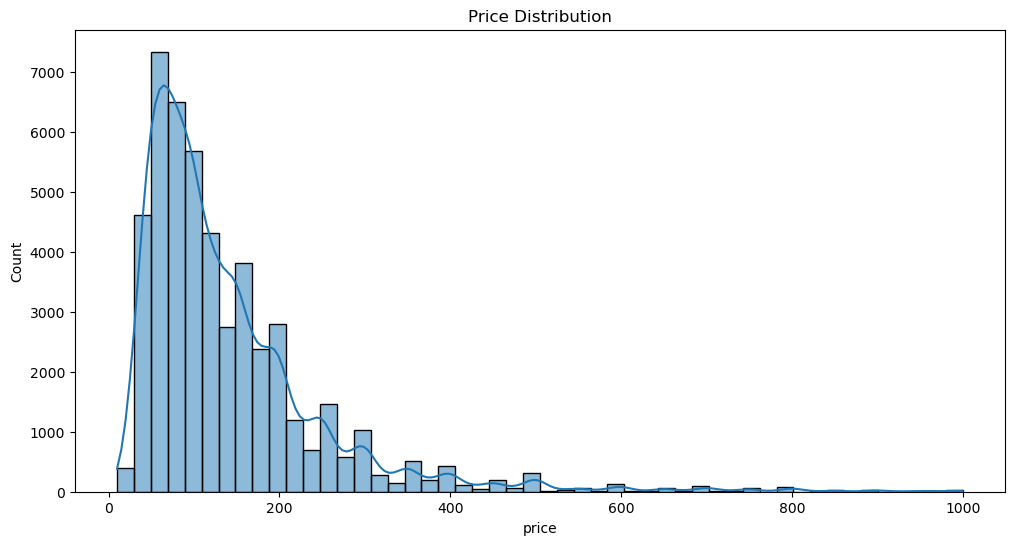

In [10]:
# Price distribution
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.histplot(df['price'], bins=50, kde=True)
plt.title("Price Distribution")
plt.show()


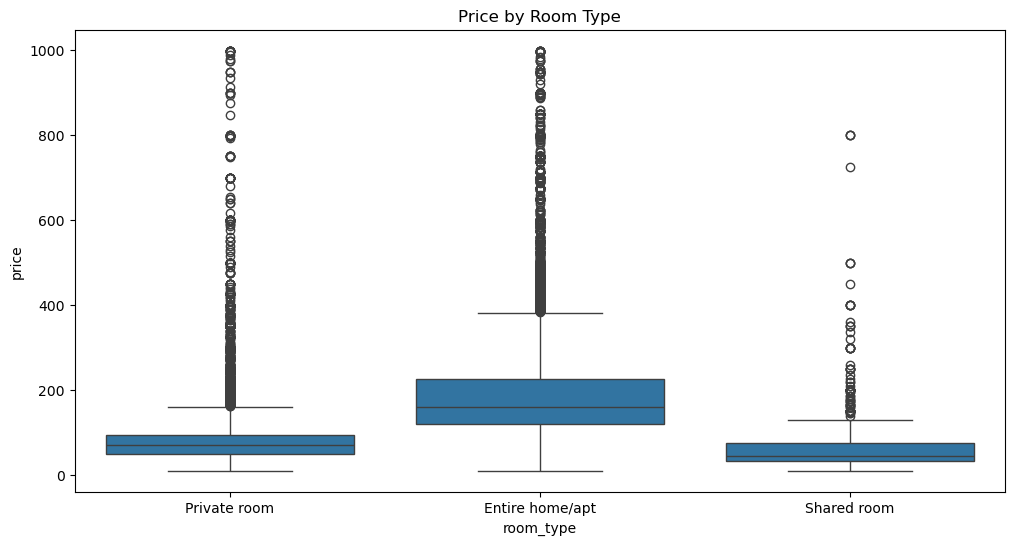

In [11]:
# Price by room type
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='room_type', y='price')
plt.title("Price by Room Type")
plt.show()



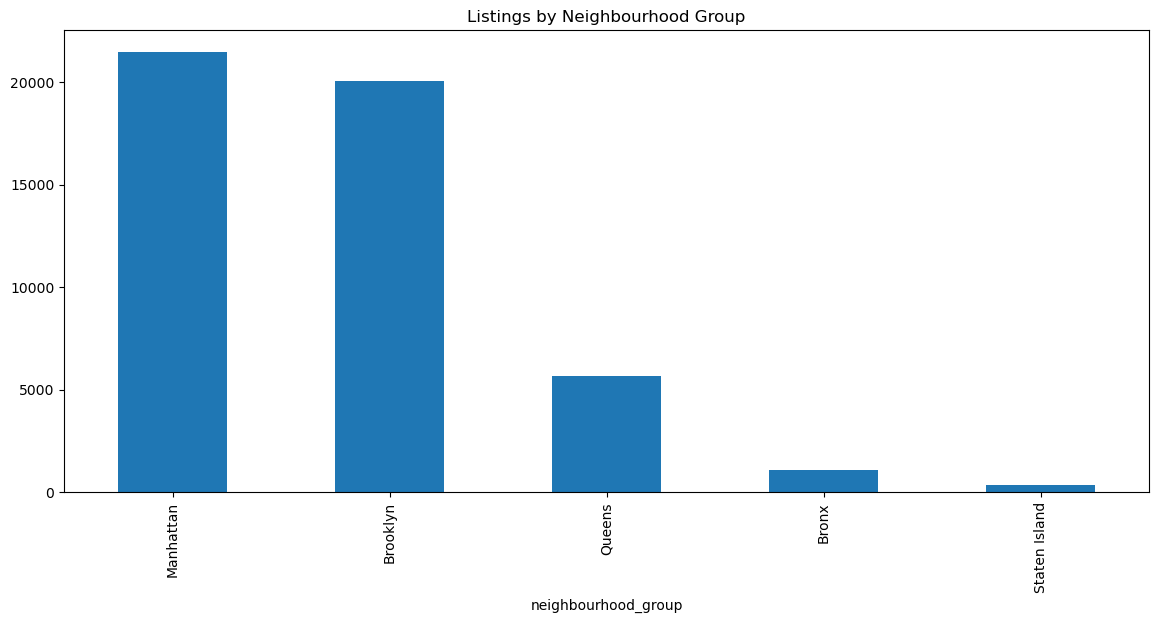

In [12]:
# Listings by neighbourhood
plt.figure(figsize=(14,6))
df['neighbourhood_group'].value_counts().plot(kind='bar')
plt.title("Listings by Neighbourhood Group")
plt.show()


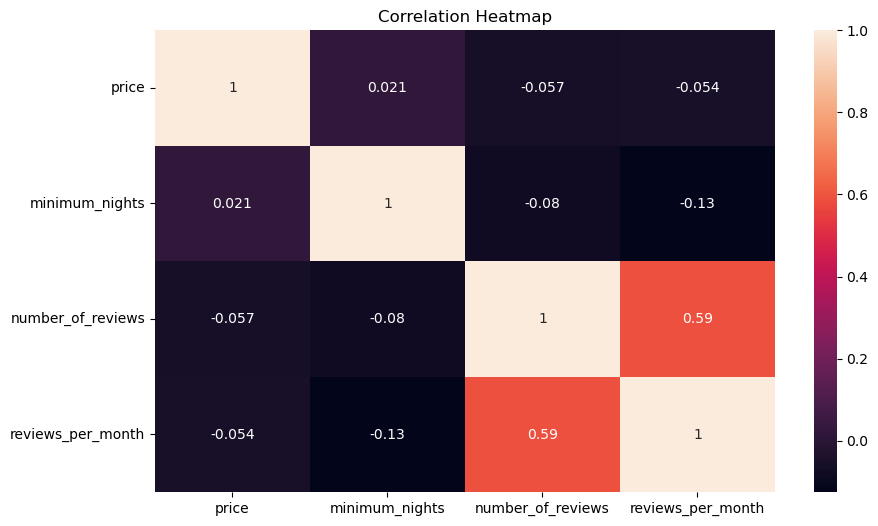

In [13]:
# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df[['price','minimum_nights','number_of_reviews','reviews_per_month']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()


In [14]:
# Advanced Analysis
df.groupby('neighbourhood')['price'].mean().sort_values(ascending=False).head(10)


neighbourhood
Fort Wadsworth       800.000000
Woodrow              700.000000
Tribeca              309.468750
NoHo                 276.246753
Flatiron District    275.052632
Neponsit             274.666667
Midtown              263.763469
SoHo                 250.057471
Willowbrook          249.000000
West Village         238.483400
Name: price, dtype: float64

In [15]:
# Revenue by neighbourhood group
df.groupby('neighbourhood_group')['estimated_revenue'].sum().sort_values(ascending=False)


neighbourhood_group
Manhattan        33064226
Brooklyn         13801807
Queens            2425050
Bronx              372404
Staten Island      175450
Name: estimated_revenue, dtype: int64

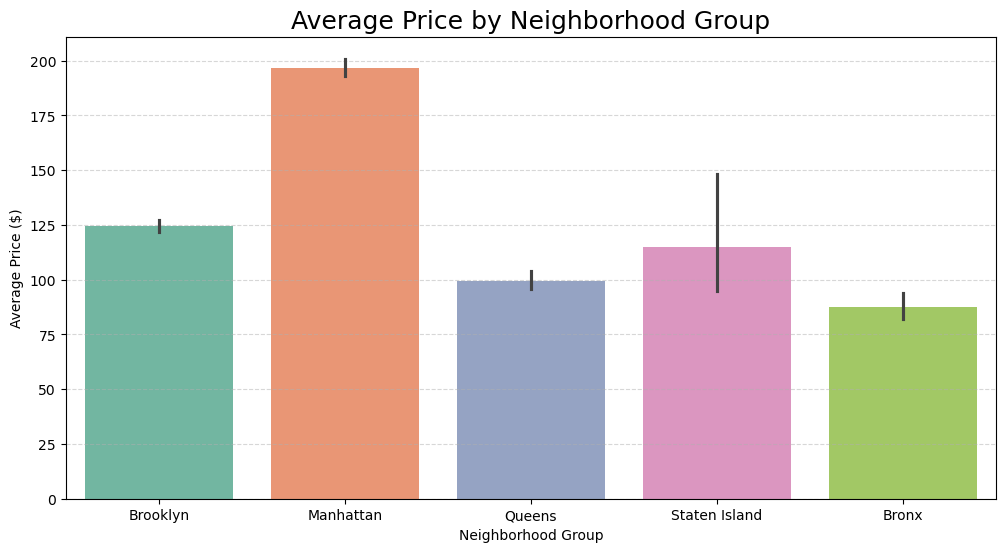

In [25]:
# Activity 
# Bar Chart — Price Distribution by Neighborhood Group
plt.figure(figsize=(12,6))

sns.barplot(
    data=df,
    x="neighbourhood_group",
    y="price",
    hue="neighbourhood_group",
    palette="Set2",
    legend=False
)

plt.title("Average Price by Neighborhood Group", fontsize=18)
plt.xlabel("Neighborhood Group")
plt.ylabel("Average Price ($)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()



In [17]:
# Univariate Analysis — availability_365
df["availability_365"].describe()


count    48895.000000
mean       112.781327
std        131.622289
min          0.000000
25%          0.000000
50%         45.000000
75%        227.000000
max        365.000000
Name: availability_365, dtype: float64

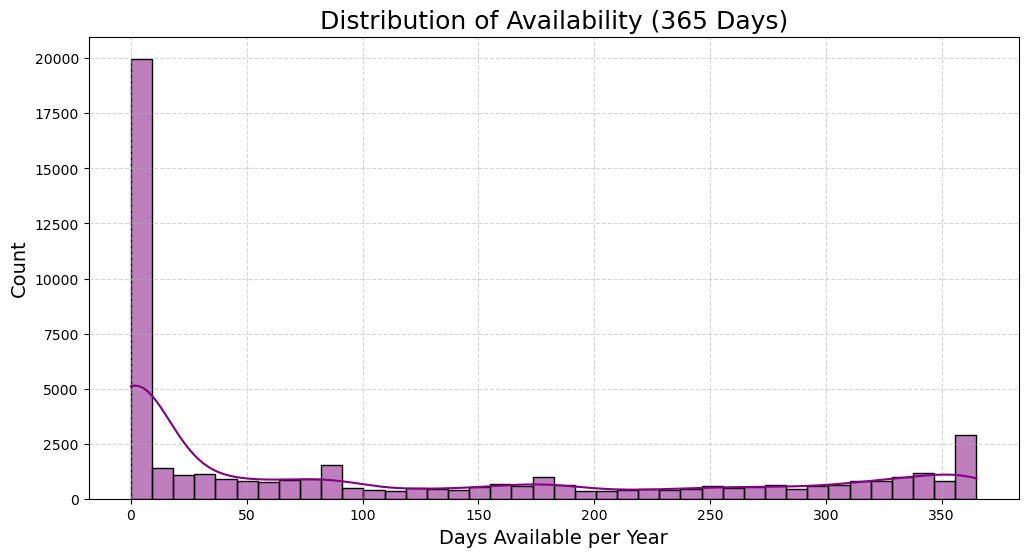

In [18]:
# Histogram
plt.figure(figsize=(12,6))
sns.histplot(df["availability_365"], bins=40, kde=True, color="purple")
plt.title("Distribution of Availability (365 Days)", fontsize=18)
plt.xlabel("Days Available per Year", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


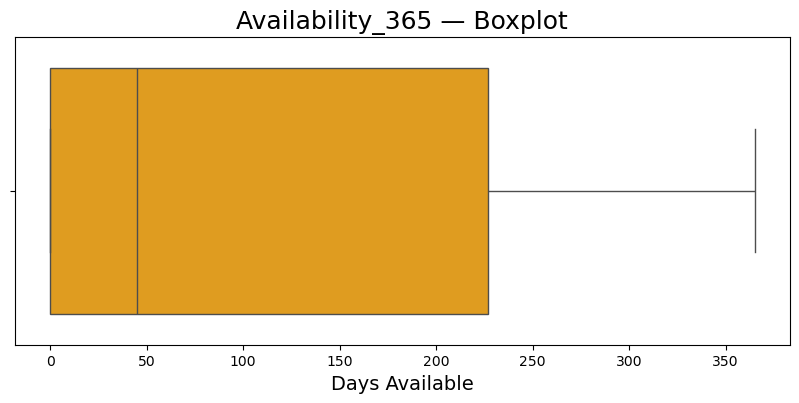

In [19]:
# Boxplot (to detect outliers)
plt.figure(figsize=(10,4))
sns.boxplot(x=df["availability_365"], color="orange")
plt.title("Availability_365 — Boxplot", fontsize=18)
plt.xlabel("Days Available", fontsize=14)
plt.show()


In [20]:
# Categorize availability levels
df["availability_category"] = pd.cut(
    df["availability_365"],
    bins=[0, 30, 180, 365],
    labels=["Low (0–30)", "Medium (31–180)", "High (181–365)"]
)

df["availability_category"].value_counts()


availability_category
High (181–365)     14364
Medium (31–180)    11724
Low (0–30)          5274
Name: count, dtype: int64

<Axes: xlabel='availability_category', ylabel='count'>

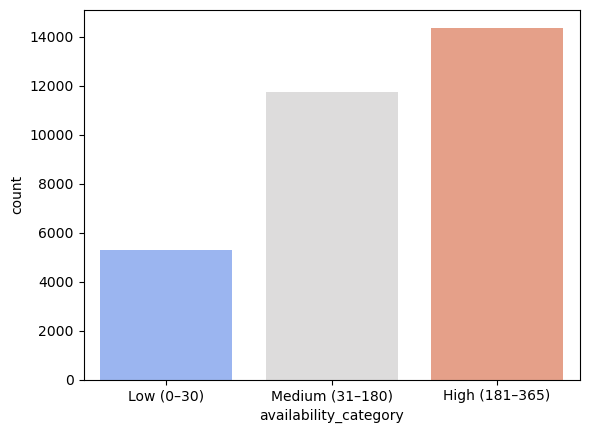

In [23]:
# Bar chart of availability categories
sns.countplot(
    data=df,
    x="availability_category",
    hue="availability_category",
    palette="coolwarm",
    legend=False
)


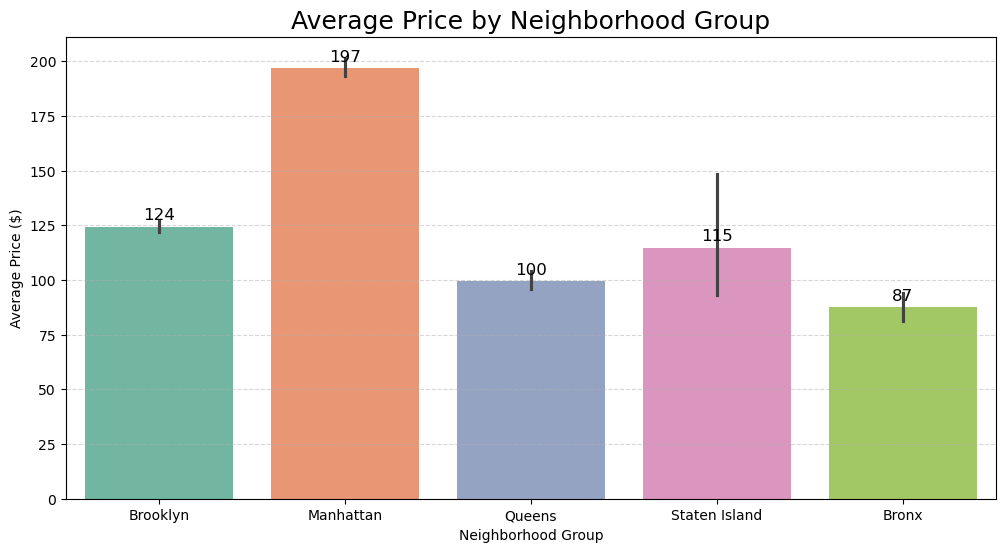

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=df,
    x="neighbourhood_group",
    y="price",
    hue="neighbourhood_group",
    palette="Set2",
    legend=False
)

# --- Add labels on each bar ---
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", fontsize=12, padding=3)

plt.title("Average Price by Neighborhood Group", fontsize=18)
plt.xlabel("Neighborhood Group")
plt.ylabel("Average Price ($)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()
